Import libraries:

In [55]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np
import shap

Import cleaned data:

In [56]:
df = pd.read_csv('clinical_trials_cleaned.csv', parse_dates=['start_date', 'completion_date'])
categorical_cols = ['phase', 'sponsor_type', 'allocation', 'intervention_model', 
                    'masking', 'primary_purpose', 'gender', 'healthy_volunteers']
for col in categorical_cols:
    df[col] = df[col].astype('category')
df.shape

(114663, 20)

Data descriptives:

In [57]:
print(df['duration_days'].describe())

count    114663.000000
mean       1011.577649
std         966.553126
min           1.000000
25%         335.000000
50%         731.000000
75%        1400.000000
max       23042.000000
Name: duration_days, dtype: float64


In [58]:
print(df['phase'].value_counts())

phase
PHASE2           30605
PHASE1           27641
PHASE3           23632
PHASE4           19691
PHASE1/PHASE2     6940
PHASE2/PHASE3     3623
EARLY_PHASE1      2531
Name: count, dtype: int64


In [59]:
print(df['sponsor_type'].value_counts())

sponsor_type
INDUSTRY     55968
OTHER        51974
NIH           2782
OTHER_GOV     1676
NETWORK       1243
FED            812
INDIV          174
UNKNOWN         34
Name: count, dtype: int64


Train-test split:

This data is based on time, so we will use a chronological split:

In [60]:
split_date = pd.Timestamp('2019-01-01') # chosen such that the training set is about 80% of the data
train = df[df['start_date'] < split_date]
test = df[df['start_date'] >= split_date]
print(train.shape, test.shape)

(89153, 20) (25510, 20)


Fit a LightGBM model:

In [61]:
feature_cols = ['phase', 'enrollment', 'sponsor_type', 'num_sites',
                'num_conditions', 'num_interventions', 'num_countries',
                'allocation', 'intervention_model', 'masking', 'primary_purpose',
                'gender', 'minimum_age', 'maximum_age', 'healthy_volunteers']

X_train = train[feature_cols].copy()
y_train = train['duration_days']
X_test = test[feature_cols].copy()
y_test = test['duration_days']

for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train, categorical_feature=categorical_cols)

preds = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 15
[LightGBM] [Info] Start training from score 1124.253732


In [62]:
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

MAE: 428.91350791124484
RMSE: 570.8270675312981


Analyze SHAP:

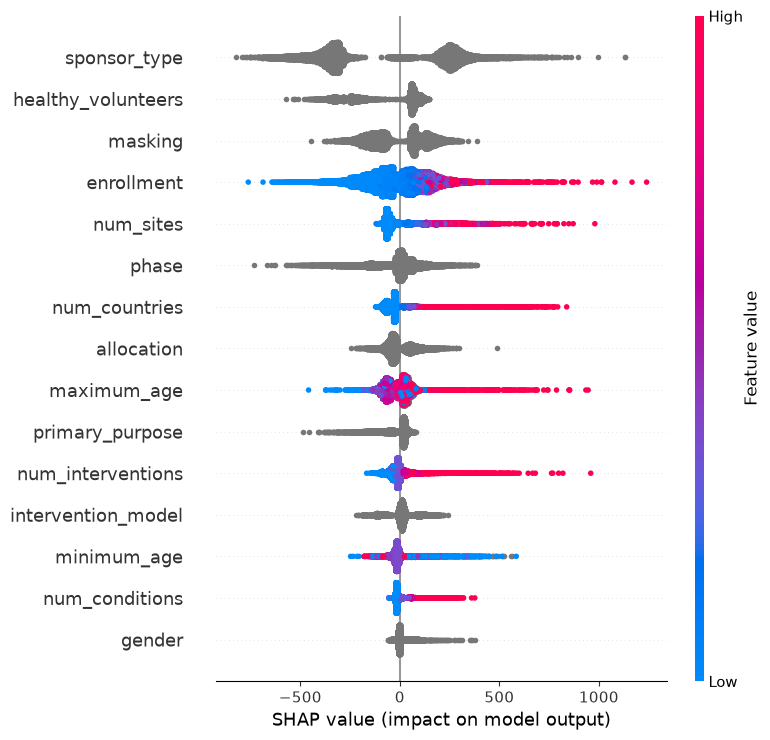

In [63]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

Fit log model:

In [64]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = lgb.LGBMRegressor(random_state=42)
model_log.fit(X_train, y_train_log, categorical_feature=categorical_cols)

preds_log = model_log.predict(X_test)
preds_original_scale = np.expm1(preds_log)

mae_log = mean_absolute_error(y_test, preds_original_scale)
rmse_log = np.sqrt(mean_squared_error(y_test, preds_original_scale))
print("MAE:", mae_log, "RMSE:", rmse_log)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 15
[LightGBM] [Info] Start training from score 6.572475
MAE: 335.0525687740788 RMSE: 463.08911115331153


Fit a log model with hyperparameter tuning:

In [65]:
train_sorted = train.sort_values('start_date')
X_train_sorted = train_sorted[feature_cols].copy()
y_train_sorted_log = np.log1p(train_sorted['duration_days'])

for col in categorical_cols:
    X_train_sorted[col] = X_train_sorted[col].astype('category')

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'min_child_samples': [10, 20, 50]
}

search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_sorted, y_train_sorted_log, categorical_feature=categorical_cols)
print("Best params:", search.best_params_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 15
[LightGBM] [Info] Start training from score 6.572475
Best params: {'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 7, 'learning_rate': 0.1}


In [66]:
best_params = {k: v for k, v in search.best_params_.items() if k != 'n_estimators'}

model_hyp = lgb.LGBMRegressor(random_state=42, n_estimators=1000, **best_params)
model_hyp.fit(X_train, y_train_log, categorical_feature=categorical_cols,
                 eval_set=[(X_test, y_test_log)], callbacks=[lgb.early_stopping(50)])

preds_hyp_log = model_hyp.predict(X_test)
preds_hyp = np.expm1(preds_hyp_log)

mae_hyp = mean_absolute_error(y_test, preds_hyp)
rmse_hyp = np.sqrt(mean_squared_error(y_test, preds_hyp))
print("MAE:", mae_hyp, "RMSE:", rmse_hyp)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 15
[LightGBM] [Info] Start training from score 6.572475
Training until validation scores don't improve for 50 rounds


f:\Stuff\School\UWaterloo\spring 2026\stat 444\Pharmaceutical Investment Analysis\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Early stopping, best iteration is:
[456]	valid_0's l2: 0.715497
MAE: 337.51687878525377 RMSE: 469.65024112945054


Fit a log model with early stopping:

In [67]:
model_early = lgb.LGBMRegressor(random_state=42, n_estimators=1000)
model_early.fit(X_train, y_train_log, categorical_feature=categorical_cols,
                 eval_set=[(X_test, y_test_log)], callbacks=[lgb.early_stopping(50)])

preds_early_log = model_early.predict(X_test)
preds_early = np.expm1(preds_early_log)

mae_early = mean_absolute_error(y_test, preds_early)
rmse_early = np.sqrt(mean_squared_error(y_test, preds_early))
print("MAE:", mae_early, "RMSE:", rmse_early)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 15
[LightGBM] [Info] Start training from score 6.572475
Training until validation scores don't improve for 50 rounds


f:\Stuff\School\UWaterloo\spring 2026\stat 444\Pharmaceutical Investment Analysis\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Early stopping, best iteration is:
[319]	valid_0's l2: 0.712968
MAE: 336.30347857398766 RMSE: 467.604702722984


Fit a model with both hyperparameter tuning and early stopping:

In [68]:
train_sorted = train.sort_values('start_date')
X_train_sorted = train_sorted[feature_cols].copy()
y_train_sorted_log = np.log1p(train_sorted['duration_days'])

for col in categorical_cols:
    X_train_sorted[col] = X_train_sorted[col].astype('category')

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [10, 20, 50]
    # n_estimators excluded, early stopping will control this instead
}

search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_estimators=1000),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_sorted, y_train_sorted_log, categorical_feature=categorical_cols)
print("Best params:", search.best_params_)

model_hyp_ear = lgb.LGBMRegressor(random_state=42, n_estimators=1000, **search.best_params_)
model_hyp_ear.fit(
    X_train, y_train_log,
    categorical_feature=categorical_cols,
    eval_set=[(X_test, y_test_log)],
    callbacks=[lgb.early_stopping(50)]
)

preds_hyp_ear_log = model_hyp_ear.predict(X_test)
preds_hyp_ear = np.expm1(preds_hyp_ear_log)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_hyp_ear = mean_absolute_error(y_test, preds_hyp_ear)
rmse_hyp_ear = np.sqrt(mean_squared_error(y_test, preds_hyp_ear))
print("MAE:", mae_hyp_ear, "RMSE:", rmse_hyp_ear)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 15
[LightGBM] [Info] Start training from score 6.572475
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

f:\Stuff\School\UWaterloo\spring 2026\stat 444\Pharmaceutical Investment Analysis\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Fit a linear regression model to compare:

In [69]:
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

lr_pipeline = Pipeline([('prep', preprocessor), ('lr', LinearRegression())])
lr_pipeline.fit(X_train.astype({c: 'object' for c in categorical_cols}), y_train_log)
lr_preds_log = lr_pipeline.predict(X_test.astype({c: 'object' for c in categorical_cols}))
lr_preds = np.expm1(lr_preds_log)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
print("MAE:", lr_mae, "RMSE:", lr_rmse)

MAE: 377.2657946572878 RMSE: 640.276959747687


The LightGBM log model with hyperparameter tuning and early stopping outperforms the linear regression log model.

Analyze SHAP of the chosen model:

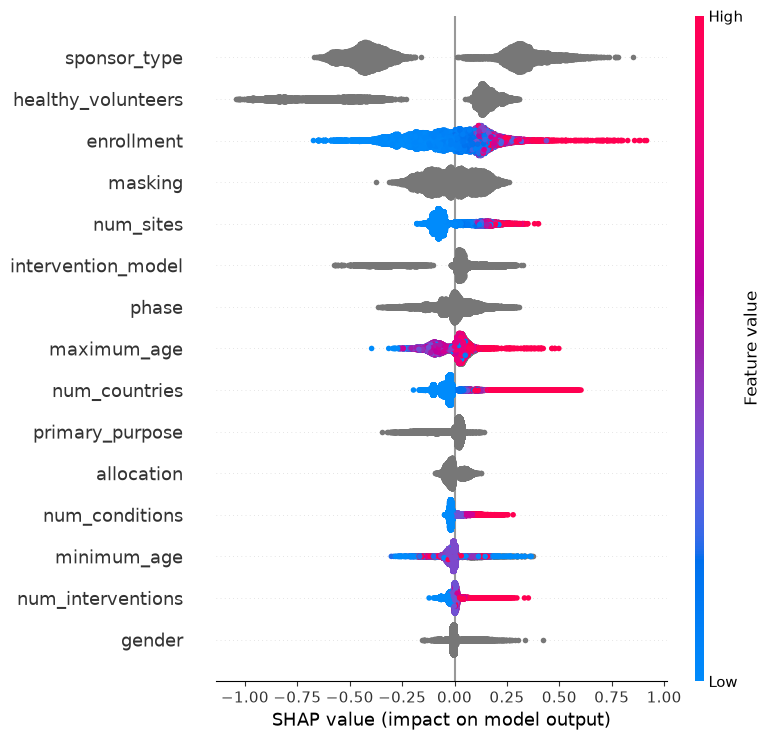

In [ ]:
explainer = shap.TreeExplainer(model_hyp_ear)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

We can look at some toy examples of how this model can work:

Set up some mock trials:

In [71]:
example_trials = pd.DataFrame([
    { # Large late-stage industry trial
        'phase': 'PHASE3', 'enrollment': 3000, 'sponsor_type': 'INDUSTRY',
        'num_sites': 150, 'num_countries': 20, 'num_conditions': 1,
        'num_interventions': 2, 'allocation': 'RANDOMIZED',
        'intervention_model': 'PARALLEL', 'masking': 'QUADRUPLE',
        'primary_purpose': 'TREATMENT', 'gender': 'ALL',
        'minimum_age': 18, 'maximum_age': 75, 'healthy_volunteers': 'No'
    },
    { # Small early-stage NIH trial
        'phase': 'PHASE1', 'enrollment': 40, 'sponsor_type': 'NIH',
        'num_sites': 2, 'num_countries': 1, 'num_conditions': 1,
        'num_interventions': 1, 'allocation': 'NON_RANDOMIZED',
        'intervention_model': 'SINGLE_GROUP', 'masking': 'NONE',
        'primary_purpose': 'TREATMENT', 'gender': 'ALL',
        'minimum_age': 18, 'maximum_age': 65, 'healthy_volunteers': 'Yes'
    },
    { # Mid-size Phase 2 rare-disease-style trial
        'phase': 'PHASE2', 'enrollment': 200, 'sponsor_type': 'INDUSTRY',
        'num_sites': 25, 'num_countries': 5, 'num_conditions': 1,
        'num_interventions': 1, 'allocation': 'RANDOMIZED',
        'intervention_model': 'PARALLEL', 'masking': 'DOUBLE',
        'primary_purpose': 'TREATMENT', 'gender': 'ALL',
        'minimum_age': 18, 'maximum_age': 80, 'healthy_volunteers': 'No'
    },
])

for col in categorical_cols:
    example_trials[col] = example_trials[col].astype('category')
example_trials = example_trials[feature_cols]

Get predictions of trial length:

In [72]:
preds_log_example = model_log.predict(example_trials)
preds_days_example = np.expm1(preds_log_example)

for i, days in enumerate(preds_days_example):
    print(f"Trial {i+1}: predicted duration = {days:.0f} days (~{days/365:.1f} years)")

Trial 1: predicted duration = 767 days (~2.1 years)
Trial 2: predicted duration = 681 days (~1.9 years)
Trial 3: predicted duration = 479 days (~1.3 years)


Create a waterfall plot to see what drove this prediction:

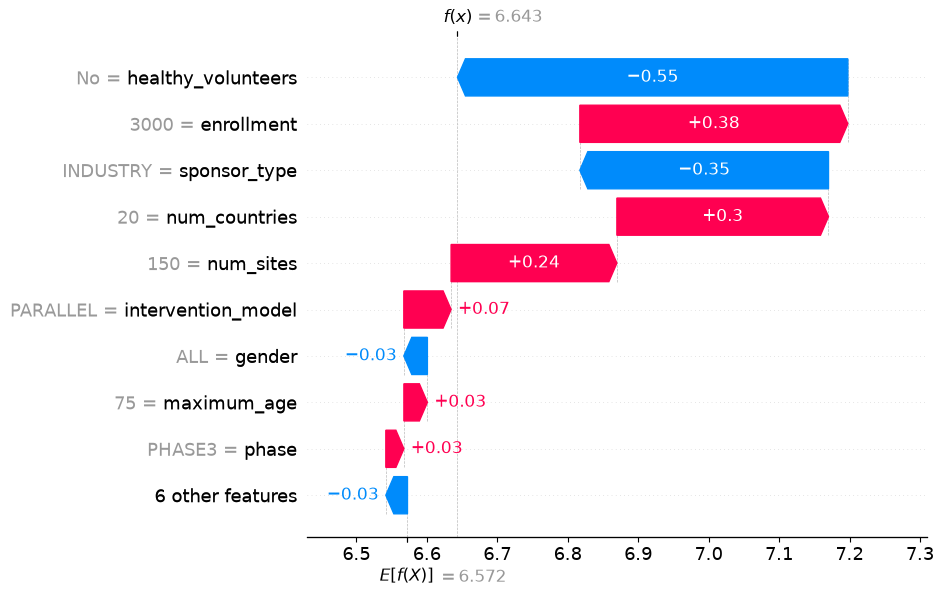

In [73]:
explainer = shap.TreeExplainer(model_log)
shap_values_example = explainer(example_trials)

shap.plots.waterfall(shap_values_example[0]) # Large late-stage industry trial

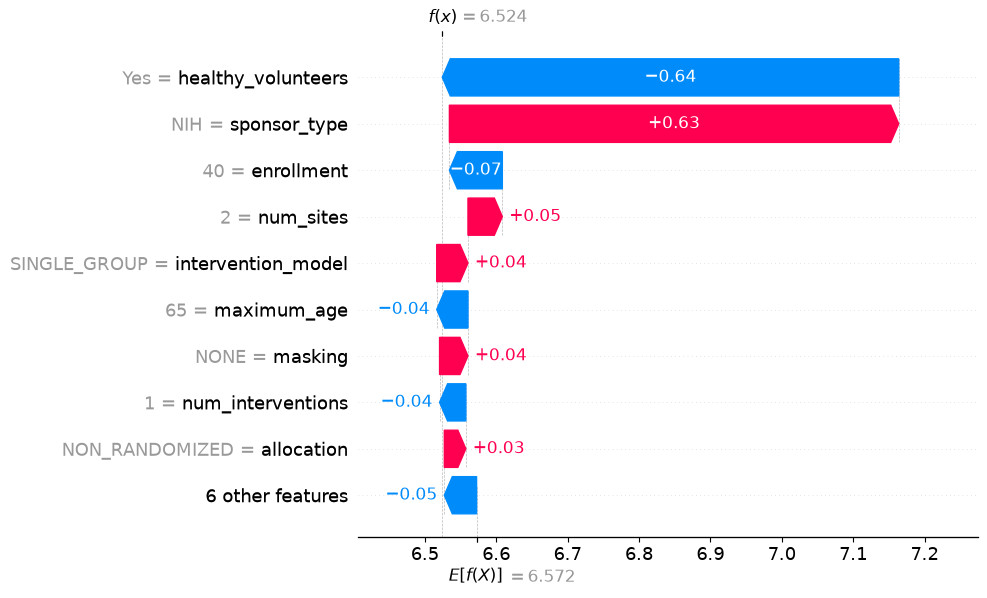

In [74]:
shap.plots.waterfall(shap_values_example[1]) # Small early-stage NIH trial

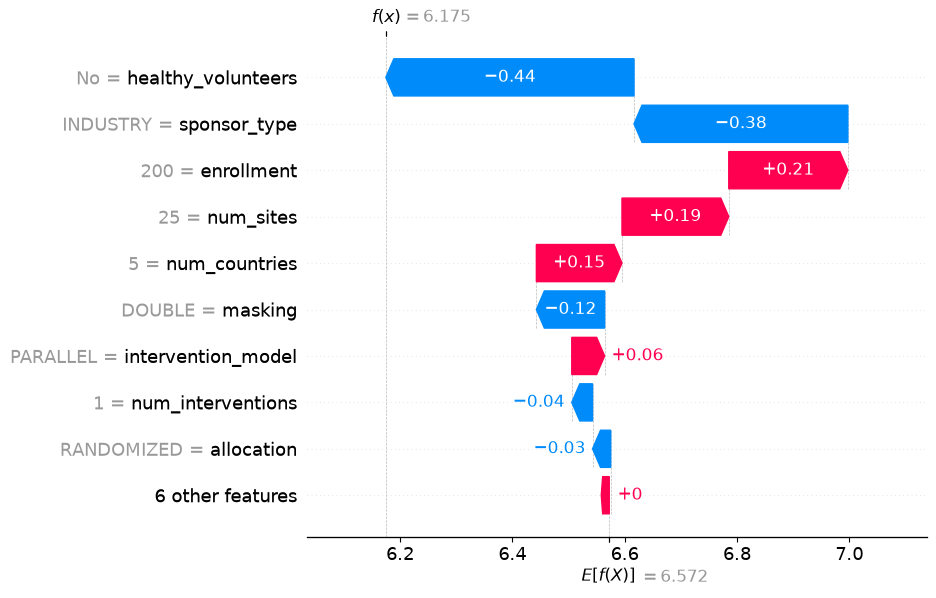

In [75]:
shap.plots.waterfall(shap_values_example[2]) # Mid-size Phase 2 rare-disease-style trial

We can connect this to investment with a toy royalty timing example:

In [76]:
predicted_duration_years = preds_days_example[0] / 365 # Large late-stage industry trial
discount_rate = 0.10 # example WACC/discount rate
illustrative_future_royalty_value = 100 # arbitrary unit, for this example let's say $million

npv_estimate = illustrative_future_royalty_value / (1 + discount_rate) ** predicted_duration_years # assuming no upfront costs

print(f"Predicted trial duration: {predicted_duration_years:.1f} years")
print(f"Illustrative NPV of a $100M future royalty stream, discounted over predicted trial duration: ${npv_estimate:.1f}M")

Predicted trial duration: 2.1 years
Illustrative NPV of a $100M future royalty stream, discounted over predicted trial duration: $81.9M


Subtract upfront costs from this prediction ($81.9M) to determine if the project will lose money.